<a href="https://colab.research.google.com/github/bonsoul/Machine_Learning-UDEMY/blob/main/Bodhi_Global_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
#read dataset
data = pd.read_csv("/content/tips.csv")

In [ ]:
data.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [ ]:
#checking shape, data types, summary stats
print("Shape",data.shape)
print(data.dtypes)
print(data.describe())

Shape (244, 7)
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [ ]:
# checking nulls, duplicates

print(data.isnull().sum())
print(data.duplicated().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
1


In [ ]:
# droping dupilicates

df = data.drop_duplicates()

### Visuals

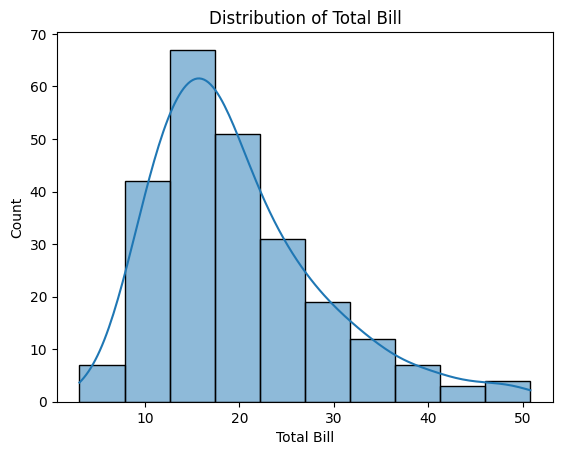

In [ ]:
# Distribution of Total Bill
sns.histplot(df['total_bill'], bins=10, kde=True)
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill')
plt.show()

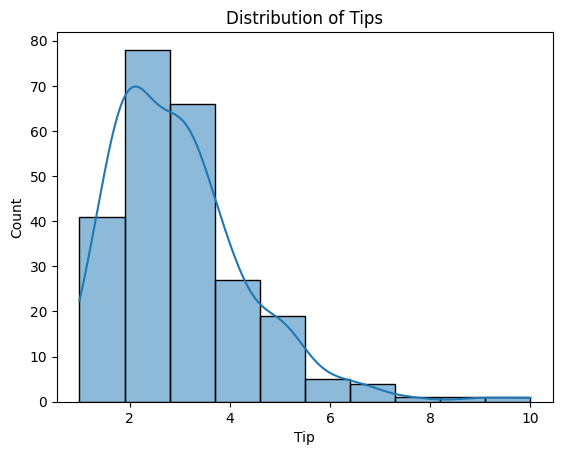

In [ ]:
sns.histplot(df['tip'], bins=10, kde=True)
plt.title('Distribution of Tips')
plt.xlabel('Tip')
plt.show()

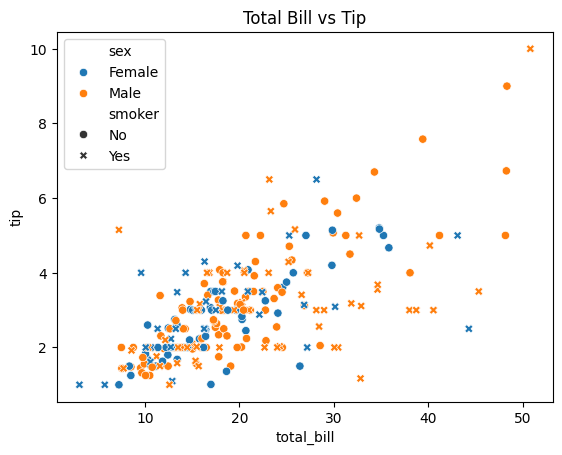

In [ ]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex', style='smoker')
plt.title('Total Bill vs Tip')
plt.show()

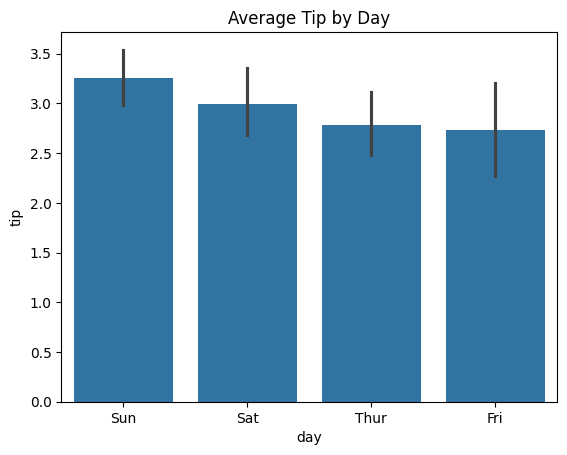

In [ ]:
sns.barplot(data=df, x='day', y='tip')
plt.title('Average Tip by Day')
plt.show()

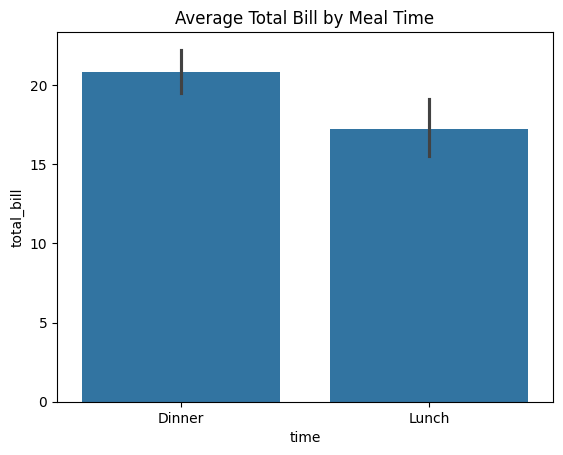

In [ ]:
#Average Total Bill by Meal Time
sns.barplot(data=df, x='time', y='total_bill')
plt.title('Average Total Bill by Meal Time')
plt.show()

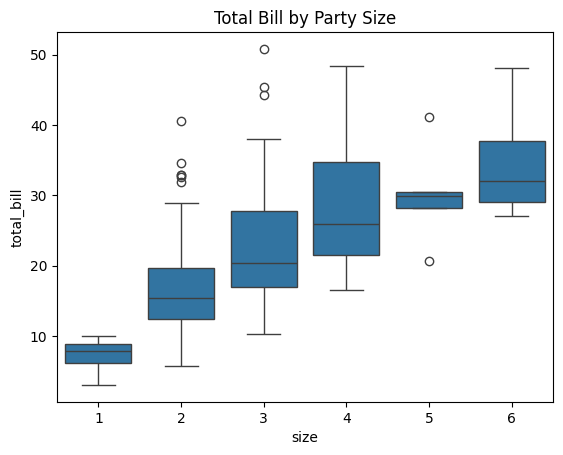

In [ ]:
#Total Bill by Party Size
sns.boxplot(data=df, x='size', y='total_bill')
plt.title('Total Bill by Party Size')
plt.show()

### simple regression model

In [ ]:
# encoding categorical variables

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)

In [ ]:
# label

X = df_encoded.drop('tip', axis=1)
y = df_encoded['tip']

In [ ]:
#  train/test split(0.8,0.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# fit linear regression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#evaluate perfomance

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 1.1730028226689764
R-squared: 0.5185656337107039


In [58]:
# features importance

X_std = (X - X.mean()) / X.std()
model_std = LinearRegression().fit(X_std, y)

importance = pd.Series(model_std.coef_, index=X.columns).sort_values(key=abs, ascending=False)

print("\nFeature importance :")
print(importance)

#top_feature = importance.index[0]
#top_value = importance.iloc[0]


Feature importance :
total_bill    0.841289
size          0.167700
day_Thur     -0.068283
day_Sat      -0.057708
smoker_Yes   -0.040462
time_Lunch    0.030391
sex_Male     -0.016432
day_Sun      -0.010787
dtype: float64


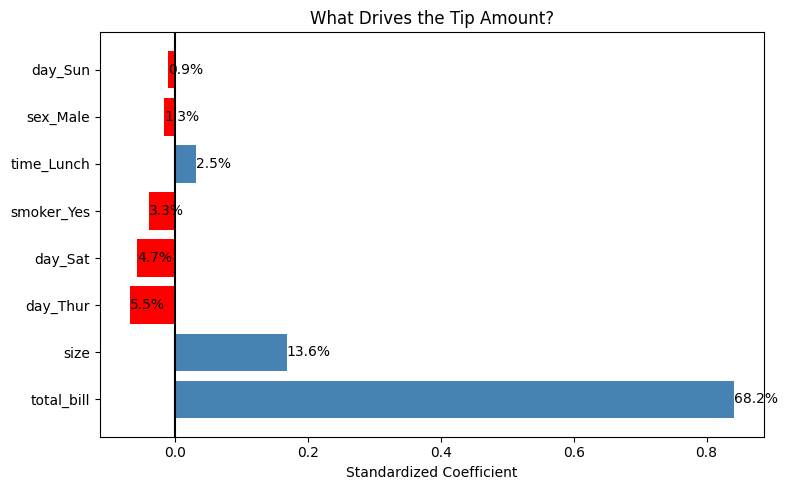

In [72]:
# % contribution
pct_share = importance.abs() / importance.abs().sum() * 100

plt.figure(figsize=(8,5))

colors = ['steelblue' if x > 0 else 'red' for x in importance.values]

bars = plt.barh(importance.index, importance.values, color=colors)

plt.axvline(0, color='black')
plt.xlabel('Standardized Coefficient')
plt.title('What Drives the Tip Amount?')

# % labels
for i, bar in enumerate(bars):
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f'{pct_share.iloc[i]:.1f}%',
             va='center')

plt.tight_layout()
plt.show()